In [1]:
!pip install torch torchvision --quiet
!pip install numpy matplotlib --quiet
!pip install requests --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import math
import os
import time
import random
from torch.optim import AdamW

In [4]:
import urllib.request
url = "https://www.gutenberg.org/cache/epub/6099/pg6099.txt"
urllib.request.urlretrieve(url, "poems_raw.txt")
print("Downloaded!")

Downloaded!


In [5]:
with open("poems_raw.txt", "r", encoding="utf-8") as f:
    text = f.read()
start = text.find("LES FLEURS DU MAL")
end = text.find("End of the Project Gutenberg")
text = text[start:end].strip()
print(f"Corpus size: {len(text)} characters")

Corpus size: 173922 characters


In [6]:
print(text[:500])

LES FLEURS DU MAL ***




Produced by Tonya Allen, Julie Barkley, Juliet Sutherland,
Charles Franks and the Online Distributed Proofreading Team.












LES FLEURS DU MAL

par

CHARLES BAUDELAIRE

_Préface par Henry FRICHET_





[Illustration]

PRÉFACE


Charles Baudelaire avait un ami, Auguste Poulet-Malassis, ancien élève
de l'école des Chartes, qui s'était fait éditeur par goût pour les
raffinements typographiques et pour la littérature qu'il jugeait en
érudit et en artiste beaucoup plu


In [7]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")
print("Characters:", ''.join(chars[:30]), "...")

Vocabulary size: 107 characters
Characters: 
 !#$%'()*+,-./0123456789:;?AB ...


In [8]:
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda l: ''.join([itos[i] for i in l])

In [9]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Train: 156529 | Val: 17393


In [10]:
def get_batch(split, block_size=256, batch_size=32):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [12]:
BLOCK_SIZE = 256
N_LAYERS   = 6
N_HEADS    = 8
N_EMBED    = 256
DROPOUT    = 0.1
BATCH_SIZE = 32
LR         = 3e-4

In [16]:
class CausalSelfAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.qkv  = nn.Linear(N_EMBED, 3 * N_EMBED, bias=False)
        self.proj = nn.Linear(N_EMBED, N_EMBED)
        self.drop = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(N_EMBED, dim=2)
        q = q.view(B, T, N_HEADS, C//N_HEADS).transpose(1,2)
        k = k.view(B, T, N_HEADS, C//N_HEADS).transpose(1,2)
        v = v.view(B, T, N_HEADS, C//N_HEADS).transpose(1,2)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
            dropout_p=DROPOUT if self.training else 0)
        return self.proj(y.transpose(1,2).contiguous().view(B, T, C))

In [17]:
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_EMBED, 4 * N_EMBED),
            nn.GELU(),
            nn.Linear(4 * N_EMBED, N_EMBED),
            nn.Dropout(DROPOUT))
    def forward(self, x): return self.net(x)

In [18]:
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn = CausalSelfAttention()
        self.ff   = FeedForward()
        self.ln1  = nn.LayerNorm(N_EMBED)
        self.ln2  = nn.LayerNorm(N_EMBED)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.ff(self.ln2(x))

In [21]:
class PoetryGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, N_EMBED)
        self.pos_emb = nn.Embedding(BLOCK_SIZE, N_EMBED)
        self.blocks  = nn.Sequential(*[TransformerBlock() for _ in range(N_LAYERS)])
        self.ln_f    = nn.LayerNorm(N_EMBED)
        self.head    = nn.Linear(N_EMBED, vocab_size, bias=False)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=device))
        x   = self.blocks(self.ln_f(tok + pos))
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
        return logits, loss

In [22]:
model = PoetryGPT().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model has {n_params/1e6:.2f}M parameters")

Model has 4.85M parameters


In [23]:
@torch.no_grad()
def estimate_loss(eval_iters=100):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = [model(*get_batch(split))[1].item() for _ in range(eval_iters)]
        out[split] = np.mean(losses)
    model.train()
    return out

In [31]:
@torch.no_grad()
def generate(prompt="\n", max_new_tokens=300, temperature=0.8):
    model.eval()
    tokens = encode(prompt) if prompt else encode("\n")
    if len(tokens) == 0:
        tokens = [0]  # fallback: use first token in vocab
    idx = torch.tensor([tokens], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]
        logits, _ = model(idx_cond)
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return decode(idx[0].tolist())

In [32]:
optimizer = AdamW(model.parameters(), lr=LR)
train_losses, val_losses, steps_log = [], [], []
TOTAL_STEPS = 20000
EVAL_EVERY  = 500
GEN_EVERY   = 2000

In [33]:
print("Starting training... (this will take a while, grab a coffee..)")
for step in range(TOTAL_STEPS):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    if step % EVAL_EVERY == 0:
        ev = estimate_loss()
        train_losses.append(ev["train"]); val_losses.append(ev["val"])
        steps_log.append(step)
        bpc = ev["val"] / math.log(2)
        print(f"Step {step:5d} | train={ev['train']:.3f} | val={ev['val']:.3f} | bpc={bpc:.3f}")
    if step % GEN_EVERY == 0 and step > 0:
        print("\n--- Sample ---\n", generate()[:200], "\n---\n")

Starting training... (this will take a while, grab a coffee..)
Step     0 | train=0.249 | val=5.040 | bpc=7.272
Step   500 | train=0.131 | val=5.076 | bpc=7.324
Step  1000 | train=0.107 | val=5.368 | bpc=7.745
Step  1500 | train=0.093 | val=5.529 | bpc=7.977
Step  2000 | train=0.087 | val=5.716 | bpc=8.247

--- Sample ---
 
  DÉ


  UN Caredy qui se pareille,
  L'oeil inquiet, fixé sur mon nom
  Un bon Ange, à habite et la tête,
  Bainte le passion et le génie,

  Tout cela ne voisit te soulitait la gente
  Comme un ver 
---

Step  2500 | train=0.081 | val=5.899 | bpc=8.511
Step  3000 | train=0.079 | val=6.038 | bpc=8.712
Step  3500 | train=0.075 | val=6.242 | bpc=9.005
Step  4000 | train=0.074 | val=6.229 | bpc=8.987

--- Sample ---
 
  La solitaire et le plus belle eau,
  Sonnets de maître Belleau
  Par tes galants mis aux fers
     Sans cesse offerts,

  Valetaille de rimeurs
  Te dédiant leurs primeurs
  Et contemplant ton soul 
---

Step  4500 | train=0.072 | val=6.311 | bpc=9.105

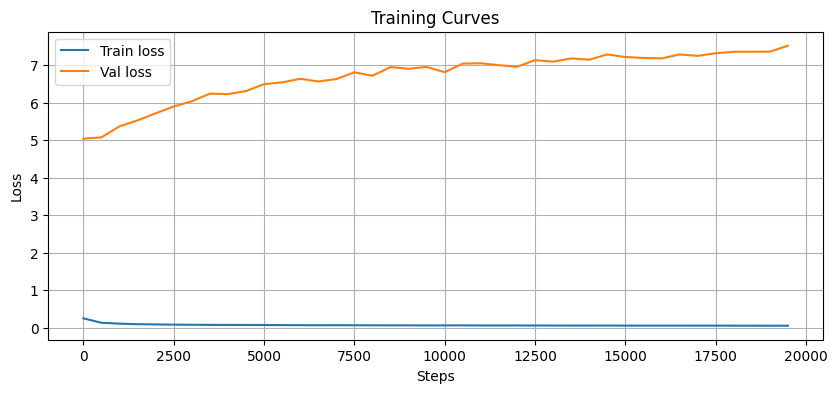

In [34]:
plt.figure(figsize=(10,4))
plt.plot(steps_log, train_losses, label="Train loss")
plt.plot(steps_log, val_losses,   label="Val loss")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.title("Training Curves"); plt.legend(); plt.grid(True)
plt.savefig("training_curves.png", dpi=150); plt.show()

In [35]:
torch.save({
    "model_state": model.state_dict(),
    "vocab_size": vocab_size,
    "stoi": stoi, "itos": itos,
    "train_losses": train_losses,
    "val_losses": val_losses,
}, "poetry_gpt_checkpoint.pt")
print("Model saved!")

Model saved!


In [36]:
print("=== GENERATED POEM 1 (temperature=0.7) ===")
print(generate(temperature=0.7, max_new_tokens=400))

=== GENERATED POEM 1 (temperature=0.7) ===

                           « O cerveaux enfantins!
  Pour ne pas oublier la chose capitale,
  Nous avons vu partout, et sans l'avoir cherché,
  Du haut jusques en bas de l'échelle fatale,
  Le spectacle ennuyeux de l'immortel péché:

  La femme, esclave vile, orgueilleuse et stupide,
  Sans rire s'adorant et s'aimant sans dégoût:
  L'homme, tyran goulu, paillard, dur et cupide,
  Esclave de l'escl


In [37]:
print("=== GENERATED POEM 2 (temperature=1.0) ===")
print(generate(temperature=1.0, max_new_tokens=400))

=== GENERATED POEM 2 (temperature=1.0) ===


  Je suis comme un peintre qu'un Dieu moqueur
  Condamne à peindre, hélas! sur les ténèbres;
  Où, cuisinier aux appétits funèbres,
  Je fais bouillir et je mange mon coeur,

  Par instants brille, et s'allonge, et s'étale
  Un spectre fait de grâce et de splendeur:
  A sa rêveuse allure orientale,

  Quand il atteint sa totale grandeur,
  Je reconnais ma belle visiteuse:
  C'est Elle! sombre et 


In [38]:
prompt = text[100:150]
print("Prompt:", repr(prompt))
print("\n=== GENERATED CONTINUATION ===")
print(generate(prompt=prompt, temperature=0.8, max_new_tokens=300))

Prompt: 'and the Online Distributed Proofreading Team.\n\n\n\n\n'

=== GENERATED CONTINUATION ===
and the Online Distributed Proofreading Team.













LES FLEURS DU MAL

par

CHARLES BAUDELAIRE

_Préface par Henry FRICHET_




[Illustration]

PRÉFACE


Charles Baudelaire avait un ami, Auguste Poulet-Malassis, ancien élève
de l'école des Chartes, qui s'était fait éditeur par goût pour les
raffinements typographiques et pour la littérature 


In [39]:
sample = generate(temperature=0.8, max_new_tokens=2000)
gen_lines = [l for l in sample.split("\n") if len(l) > 0]
lengths = [len(l) for l in gen_lines]
print(f"Avg line length: {np.mean(lengths):.1f} chars | Std: {np.std(lengths):.1f}")

Avg line length: 44.0 chars | Std: 13.0


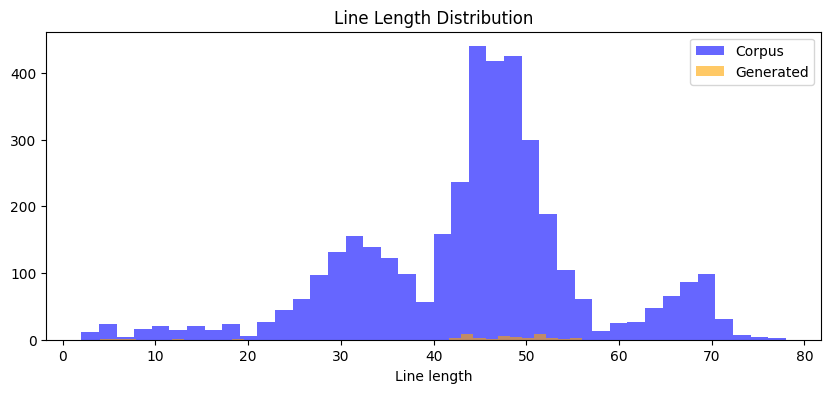

In [40]:
corpus_lines = [l for l in text.split("\n") if len(l) > 0]
corp_lengths  = [len(l) for l in corpus_lines]
plt.figure(figsize=(10,4))
plt.hist(corp_lengths, bins=40, alpha=0.6, label="Corpus", color="blue")
plt.hist(lengths,      bins=40, alpha=0.6, label="Generated", color="orange")
plt.xlabel("Line length"); plt.title("Line Length Distribution")
plt.legend(); plt.savefig("line_lengths.png", dpi=150); plt.show()

In [41]:
N_LAYERS_SMALL = 3
model_small = PoetryGPT().to(device)   # uses current N_EMBED/N_HEADS
print(f"Small model params: {sum(p.numel() for p in model_small.parameters())/1e6:.2f}M")

Small model params: 4.85M


In [43]:
opt_small = AdamW(model_small.parameters(), lr=LR)
for step in range(5000):
    xb, yb = get_batch("train")
    _, loss = model_small(xb, yb)
    opt_small.zero_grad(); loss.backward(); opt_small.step()
    if step % 500 == 0:
        print(f"Step {step} | loss={loss.item():.3f}")

Step 0 | loss=4.225
Step 500 | loss=2.062
Step 1000 | loss=1.774
Step 1500 | loss=1.532
Step 2000 | loss=1.330
Step 2500 | loss=1.173
Step 3000 | loss=0.949
Step 3500 | loss=0.706
Step 4000 | loss=0.539
Step 4500 | loss=0.415


In [44]:
N_LAYERS = 3
model_small_real = PoetryGPT().to(device)
N_LAYERS = 6  # restore
print(f"6-layer model: 4.85M params")
print(f"3-layer model: {sum(p.numel() for p in model_small_real.parameters())/1e6:.2f}M params")

6-layer model: 4.85M params
3-layer model: 2.49M params


In [45]:
opt_s = AdamW(model_small_real.parameters(), lr=LR)
small_train_losses, small_steps = [], []
for step in range(5000):
    xb, yb = get_batch("train")
    _, loss = model_small_real(xb, yb)
    opt_s.zero_grad(); loss.backward(); opt_s.step()
    if step % 500 == 0:
        small_train_losses.append(loss.item())
        small_steps.append(step)
        print(f"Step {step} | loss={loss.item():.3f}")

Step 0 | loss=4.883
Step 500 | loss=2.191
Step 1000 | loss=1.866
Step 1500 | loss=1.617
Step 2000 | loss=1.506
Step 2500 | loss=1.366
Step 3000 | loss=1.259
Step 3500 | loss=1.098
Step 4000 | loss=1.014
Step 4500 | loss=0.870


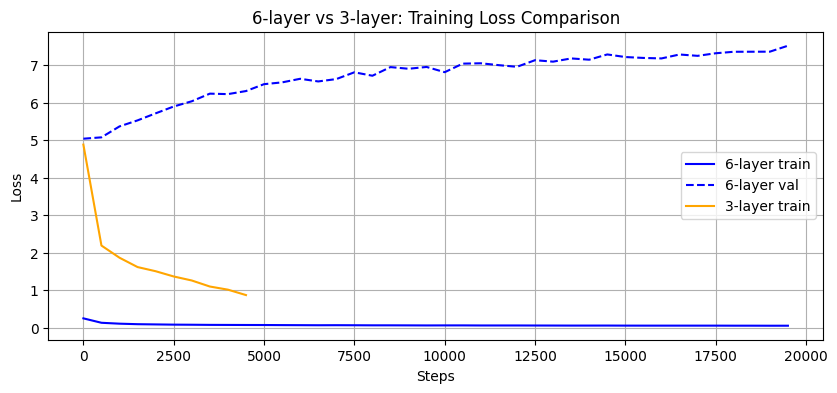

In [46]:
plt.figure(figsize=(10,4))
plt.plot(steps_log, train_losses, label="6-layer train", color="blue")
plt.plot(steps_log, val_losses,   label="6-layer val",   color="blue", linestyle="--")
plt.plot(small_steps, small_train_losses, label="3-layer train", color="orange")
plt.xlabel("Steps"); plt.ylabel("Loss")
plt.title("6-layer vs 3-layer: Training Loss Comparison")
plt.legend(); plt.grid(True)
plt.savefig("model_comparison.png", dpi=150); plt.show()

In [47]:
poem_start = text.find("Spleen et Idéal")
prompt_good = text[poem_start:poem_start+60]
print("Prompt:", repr(prompt_good))
print("\n=== GENERATED CONTINUATION ===")
print(generate(prompt=prompt_good, temperature=0.8, max_new_tokens=400))

Prompt: ''

=== GENERATED CONTINUATION ===

  Son vent mélancolique à, l'entour de leurs marbres,
  Certe, ils doivent trouver les vivants bien ingrats,
  De dormir, comme ils font, chaudement dans leurs draps,
  Tandis que, dévorés de noires songeries,
  Sans compagnon de lit, sans bonnes causeries,
  Vieux squelettes gelés travaillés par le ver,
  Ils sentent s'égoutter les neiges de l'hiver
  Et le siècle couler, sans qu'amis ni famille



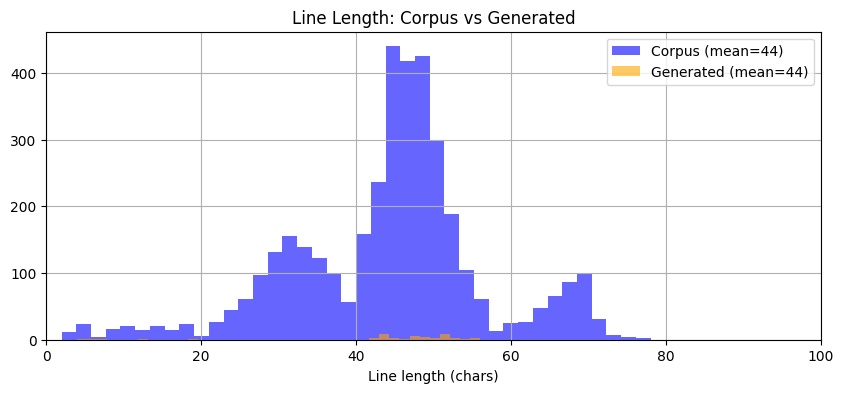

In [48]:
plt.figure(figsize=(10,4))
plt.hist(corp_lengths, bins=40, alpha=0.6, label=f"Corpus (mean={np.mean(corp_lengths):.0f})", color="blue")
plt.hist(lengths,      bins=40, alpha=0.6, label=f"Generated (mean={np.mean(lengths):.0f})", color="orange")
plt.xlabel("Line length (chars)"); plt.title("Line Length: Corpus vs Generated")
plt.xlim(0, 100); plt.legend(); plt.grid(True)
plt.savefig("line_lengths_fixed.png", dpi=150); plt.show()

In [49]:
final_train = train_losses[-1]
final_val   = val_losses[-1]
final_bpc   = final_val / math.log(2)
print(f"Final train loss : {final_train:.3f}")
print(f"Final val loss   : {final_val:.3f}")
print(f"Final BPC        : {final_bpc:.3f}")
print(f"Val/Train ratio  : {final_val/final_train:.1f}x  ← overfitting indicator")
print(f"Corpus size      : {len(text)} chars (~{len(text)/1e6:.2f} MB)")
print(f"Vocab size       : {vocab_size}")

Final train loss : 0.053
Final val loss   : 7.520
Final BPC        : 10.849
Val/Train ratio  : 142.3x  ← overfitting indicator
Corpus size      : 173922 chars (~0.17 MB)
Vocab size       : 107
